In [1]:
from google.colab import files

uploaded = files.upload()

Saving placement_predict_50k Dataset.csv to placement_predict_50k Dataset.csv


In [2]:
import pandas as pd

filename = list(uploaded.keys())[0]
df = pd.read_csv(filename)

print("Dataset Shape:", df.shape)

print("\nFirst 5 Rows:")
display(df.head())

print("\nColumn Names:")
print(df.columns.tolist())

print("\nMissing Values:", df.isna().sum().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

Dataset Shape: (50000, 32)

First 5 Rows:


,StudentID,Gender,City,CollegeTier,Stream,Specialisation,Hostel,HistoryOfBacklogs,SGPA_Sem1,SGPA_Sem2,...,Publications,AptitudeTestScore,SoftSkillsRating,CodingTestScore,MockInterviewScore,ExtraCurricular,CGPA_Tier,PlacementStatus,IsAnomaly,Salary Package
0,1,Male,Ahmedabad,Tier2,ECE,Networking,No,No,6.02,6.54,...,0,66.7,2.2,49.4,47.8,0,Low,0,0,0.00
1,2,Female,Mumbai,Tier2,ECE,DataScience,Yes,Yes,5.84,5.12,...,0,48.2,2.4,26.7,25.8,0,Low,0,0,0.00
2,3,Male,Kolkata,Tier2,IT,DataScience,Yes,No,4.91,5.29,...,0,73.8,2.8,67.7,41.5,0,Low,1,0,3.89
3,4,Male,Jaipur,Tier1,CS,AI,No,No,7.67,8.03,...,0,69.8,2.7,66.9,48.0,0,Mid,1,0,8.37
4,5,Male,Pune,Tier2,IT,DataScience,Yes,No,8.14,8.97,...,1,73.1,2.1,71.7,61.7,1,High,1,0,18.99



Column Names:
['StudentID', 'Gender', 'City', 'CollegeTier', 'Stream', 'Specialisation', 'Hostel', 'HistoryOfBacklogs', 'SGPA_Sem1', 'SGPA_Sem2', 'SGPA_Sem3', 'SGPA_Sem4', 'SGPA_Sem5', 'SGPA_Sem6', 'SGPA_Sem7', 'SGPA_Sem8', 'CGPA', 'AttendancePercent', 'Internships', 'Projects', 'Workshops', 'Certifications', 'Publications', 'AptitudeTestScore', 'SoftSkillsRating', 'CodingTestScore', 'MockInterviewScore', 'ExtraCurricular', 'CGPA_Tier', 'PlacementStatus', 'IsAnomaly', 'Salary Package']

Missing Values: 19976

Duplicate Rows: 0


In [3]:
print("Target Distribution:")
print(df["PlacementStatus"].value_counts())

print("\nTarget Percentages:")
print(df["PlacementStatus"].value_counts(normalize=True) * 100)

print("\nMissing Values by Column:")
missing = df.isna().sum()
display(missing[missing > 0].sort_values(ascending=False))

Target Distribution:
PlacementStatus
1    32856
0    17144
Name: count, dtype: int64

Target Percentages:
PlacementStatus
1    65.712
0    34.288
Name: proportion, dtype: float64

Missing Values by Column:


,0
MockInterviewScore,4957
Workshops,4488
AptitudeTestScore,4029
SoftSkillsRating,3526
CodingTestScore,2976


In [4]:
target = "PlacementStatus"

X = df.drop(columns=["PlacementStatus", "StudentID", "Salary Package"])
y = df[target]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

print("\nNumerical Features:")
print(X.select_dtypes(include="number").columns.tolist())

print("\nCategorical Features:")
print(X.select_dtypes(exclude="number").columns.tolist())

Features Shape: (50000, 29)
Target Shape: (50000,)

Numerical Features:
['SGPA_Sem1', 'SGPA_Sem2', 'SGPA_Sem3', 'SGPA_Sem4', 'SGPA_Sem5', 'SGPA_Sem6', 'SGPA_Sem7', 'SGPA_Sem8', 'CGPA', 'AttendancePercent', 'Internships', 'Projects', 'Workshops', 'Certifications', 'Publications', 'AptitudeTestScore', 'SoftSkillsRating', 'CodingTestScore', 'MockInterviewScore', 'ExtraCurricular', 'IsAnomaly']

Categorical Features:
['Gender', 'City', 'CollegeTier', 'Stream', 'Specialisation', 'Hostel', 'HistoryOfBacklogs', 'CGPA_Tier']


In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Features:", X_train.shape)
print("Testing Features:", X_test.shape)
print("Training Target:", y_train.shape)
print("Testing Target:", y_test.shape)

print("\nTraining Target Distribution:")
print(y_train.value_counts())

print("\nTesting Target Distribution:")
print(y_test.value_counts())

Training Features: (40000, 29)
Testing Features: (10000, 29)
Training Target: (40000,)
Testing Target: (10000,)

Training Target Distribution:
PlacementStatus
1    26285
0    13715
Name: count, dtype: int64

Testing Target Distribution:
PlacementStatus
1    6571
0    3429
Name: count, dtype: int64


In [6]:
import numpy as np

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

numeric_features = X_train.select_dtypes(include=np.number).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=np.number).columns.tolist()

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features)
])

print("Numerical features:", len(numeric_features))
print("Categorical features:", len(categorical_features))
print("Preprocessing pipeline created successfully.")

Numerical features: 21
Categorical features: 8
Preprocessing pipeline created successfully.


In [7]:
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])

logistic_model.fit(X_train, y_train)

y_pred = logistic_model.predict(X_test)
y_prob = logistic_model.predict_proba(X_test)[:, 1]

print("Logistic Regression training completed.")
print("Predictions generated successfully.")

Logistic Regression training completed.
Predictions generated successfully.


In [8]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("Model Evaluation")
print("-----------------")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

Model Evaluation
-----------------
Accuracy : 0.9211
Precision: 0.9278
Recall   : 0.9542
F1 Score : 0.9408
ROC-AUC  : 0.9801


Confusion Matrix:
[[2941  488]
 [ 301 6270]]


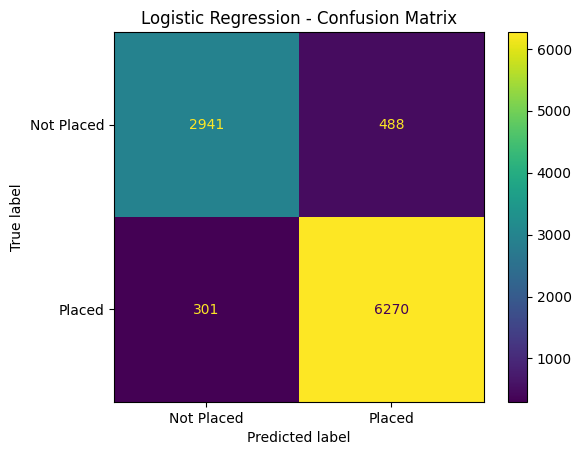

In [9]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not Placed", "Placed"]
)

disp.plot()
plt.title("Logistic Regression - Confusion Matrix")
plt.show()

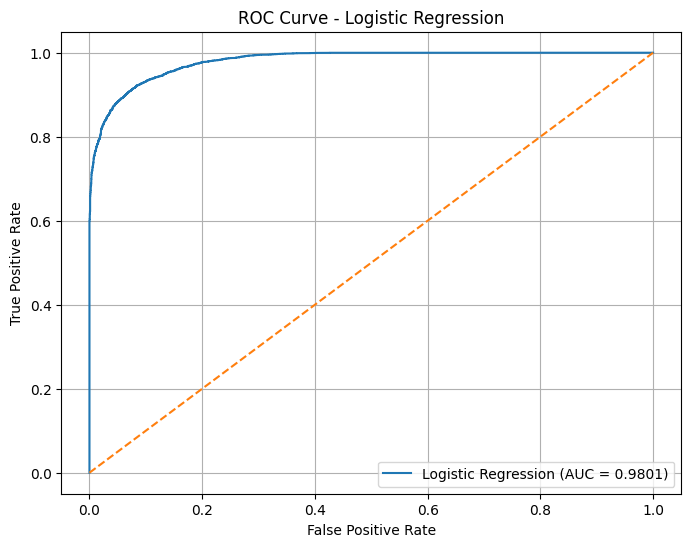

In [10]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.grid()
plt.show()

In [11]:
from sklearn.metrics import classification_report
from google.colab import files

print("Classification Report")
print("=====================")

report = classification_report(
    y_test,
    y_pred,
    target_names=["Not Placed", "Placed"]
)

print(report)

results_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"],
    "Score": [accuracy, precision, recall, f1, roc_auc]
})

results_df.to_csv("Session_5_Logistic_Regression_Results.csv", index=False)

print("\nResults saved as:")
print("Session_5_Logistic_Regression_Results.csv")

files.download("Session_5_Logistic_Regression_Results.csv")

Classification Report
              precision    recall  f1-score   support

  Not Placed       0.91      0.86      0.88      3429
      Placed       0.93      0.95      0.94      6571

    accuracy                           0.92     10000
   macro avg       0.92      0.91      0.91     10000
weighted avg       0.92      0.92      0.92     10000


Results saved as:
Session_5_Logistic_Regression_Results.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>